# Reglas de asociación
#### Mineria de Datos
##### Por Johel Santiago Arias Becerra

In [ ]:
# Propósito: instalar dependencias solo si el entorno no las tiene.
# !pip install pandas openpyxl spacy rapidfuzz matplotlib seaborn networkx scikit-learn
# !python -m spacy download es_core_news_sm

Se realiza la importacion de librerías necesarias

In [1]:
# Propósito: importar librerías, definir parámetros globales y preparar el entorno del análisis.
from __future__ import annotations

import re
import unicodedata
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
import spacy
from sklearn.preprocessing import MultiLabelBinarizer

Y se definen los parámetros globales

In [ ]:
# ── Configuración global ──────────────────────────────
DATASET_PATH = Path('data/dataset.xlsx')
SHEET_NAME = 'Respuestas de formulario 1'
EDAD_BINS = [0, 25, 35, 50, 100]
EDAD_LABELS = ['Joven', 'Adulto joven', 'Adulto', 'Senior']
OUTPUT_PATH = Path('df_procesado.xlsx')
# ─────────────────────────────────────────────────────

nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

## 1. Carga y descripción de los datos

la fuente de los datos del dataset utilizado se tomaron a partir de una encuenta propia con un total de 200 datos segun lo comentado en clase

Se utilizaron los datos recopilados por el fomulario enviado por el profesor mas informacion adicional recopilada con mi propio formulario

Estos datos fueron exportados a excel y utilizados para las reglas de asociacion

Por lo tanto, inicialmente se lee el dataset en excel para comenzar a trabajar los datos


In [6]:
# Propósito: ubicar la ruta efectiva del dataset y validar su existencia antes de cargarlo.
dataset_file = DATASET_PATH
df = pd.read_excel(dataset_file, sheet_name=SHEET_NAME)
df.head()

,Marca temporal,EDAD,GENERO,ESTRATO NSE,CIUDAD DE ORIGEN,Con quien vive actualmente,Numero de personas en el hogar,Quien realiza las compras en el Hogar,Tu misión de compra es abastecer tu hogar. Con que frecuencia lo haces.,Lugar principal de compra,Presupuesto Mensual aproximado,Alimentos Básicos,Proteinas,Bebidas,Snacks y otros,Delikatessen,Aseo para el Hogar,Aseo Personal,ultima
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante..."
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera..."
3,2026-04-01 15:21:00,25,Masculino,E3,Medellín,Familia,6,Compartido,Mensual,"Supermercado (Exito, Jumbo, Etc)",2000000,"Lentejas, Frijoles, Harinas, Pastas","Carne de Res, Pollo","Leche, Café",ninguno,Salsas,"Detergente, Blanqueadores, Cera, Desinfectante...","Protección Femenina, Jabon tocador, Hilo Denta...","leche, Jabon tocador, pan, Carne de Res, arroz..."
4,2026-04-01 21:55:00,21,Masculino,E3,Bogotá,Familia,4,Yo,Mensual,"Supermercado (Exito, Jumbo, Etc)",1200000,Lentejas,"Pollo, Huevos",Agua,ninguno,"Salsas, Quesos, Cervezas","ambientadores, Blanqueadores, Desinfectante, L...","Crema dental, Protección Femenina, Enjuague Bu...",aceite\nProtección Femenina\nSuavizantes\nBlan...


En este dataframe, se encuentran los siguientes datos.

 - EDAD: Edad del encuestado expresada en años.
 - GENERO: Identidad de género
 - ESTRATO NSE: Estado socieconomico del hogar según la clasificación establecida
 - CIUDAD DE ORIGEN: Ciudad de origen del encuestado
 - Con quien vive actualmente: Personas con las que convive el encuestado
 - Numero de personas en el hogar: Total de personal con las que vive el encuestado
 - Quien realiza las compras en el Hogar: Quien realiza las compras del hogar
 - Tu misión de compra es abastecer tu hogar. Con que frecuencia lo haces.: La frecuencia con la que el encuestado realiza compras para abastecer el hogar
 - Lugar principal de compra: Establecimiento donde el encuestado realiza sus compras
 - Presupuesto Mensual aproximado: Valor estimado de dinero destinado mensualmente a las compras
 - Alimentos Básicos: Lista de productos básicos
 - Proteinas: Proteinas consumidas o compradas
 - Bebidas: Tipos de bebidas compradas
 - Snacks y otros: Tipos de snacks u otros productos comprados
 - Delikatessen: Tipos de productos especiales o gourmet comprados
 - Aseo para el Hogar: Tipos de productos de aseo para el hogar comprados
 - Aseo Personal: Tipos de productos de aseo personal comprados
 - ultima: Otro tipo de productos comprados

# 2. Preprocesamiento y limpieza de datos

Se definen los objetos para renombrar las columnas dado por el objeto column_rename_map.

Asi mismo, se define el arreglo rows_to_cols que indica las columnas cuya informacion se debe pasar a la estructura one-hot

Y finalmente la lista de columnas con informacion demografica y que no se debe pasar a estructuracion one-hot dado por cols_demograficas


In [ ]:
column_rename_map = {
    "marca temporal": "fecha",
    "edad": "edad",
    "genero": "genero",
    "estrato nse": "estrato_nse",
    "ciudad de origen": "ciudad_origen",
    "con quien vive actualmente": "quien_vive",
    "numero de personas en el hogar": "num_personas",
    "quien realiza las compras en el hogar": "quien_compra",
    "tu misión de compra...": "mision_compra",
    "lugar principal de compra": "canal_compra",
    "presupuesto mensual aproximado": "gasto",
    "alimentos básicos": "alimentos_basicos",
    "proteinas": "proteinas",
    "bebidas": "bebidas",
    "snacks y otros": "snacks",
    "delikatessen": "delikatessen",
    "aseo para el hogar": "aseo_hogar",
    "aseo personal": "aseo_personal",
    "ultima": "otros",
}

rows_to_cols = [
    "alimentos_basicos",
    "proteinas",
    "bebidas",
    "snacks",
    "delikatessen",
    "aseo_hogar",
    "aseo_personal",
    "otros",
]

cols_demograficas = [
    "fecha",
    "edad",
    "genero",
    "estrato_nse",
    "ciudad_origen",
    "quien_vive",
    "num_personas",
    "quien_compra",
    "mision_compra",
    "canal_compra",
    "gasto",
    "grupo_edad",
]

Luego se realiza la estandarizacion de los nombres de columnas partiendo de la eliminacion de espacios, y ajustando cada una de las columnas a minusculas y buscando el valor definido en column_rename_map para el renombramiento correspondiente.

De tal forma que al observar la informacion del df se puede ver toda la informacion con los nuevos nombres de columnas

In [12]:
# Propósito: estandarizar nombres de columnas y corregir variantes para mantener consistencia semántica.
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns=column_rename_map)

# Renombrado robusto para variantes largas de la columna de misión de compra.
if "mision_compra" not in df.columns:
    mission_candidates = [
        col
        for col in df.columns
        if col.startswith("tu misión de compra")
        or col.startswith("tu mision de compra")
    ]
    if mission_candidates:
        df = df.rename(columns={mission_candidates[0]: "mision_compra"})

df.head()

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,gasto,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros,grupo_edad
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000.0,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante...",Joven
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000.0,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...,Joven
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000.0,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera...",Joven
3,2026-04-01 15:21:00,25,Masculino,E3,Medellín,Familia,6,Compartido,Mensual,"Supermercado (Exito, Jumbo, Etc)",2000000.0,"Lentejas, Frijoles, Harinas, Pastas","Carne de Res, Pollo","Leche, Café",ninguno,Salsas,"Detergente, Blanqueadores, Cera, Desinfectante...","Protección Femenina, Jabon tocador, Hilo Denta...","leche, Jabon tocador, pan, Carne de Res, arroz...",Joven
4,2026-04-01 21:55:00,21,Masculino,E3,Bogotá,Familia,4,Yo,Mensual,"Supermercado (Exito, Jumbo, Etc)",1200000.0,Lentejas,"Pollo, Huevos",Agua,ninguno,"Salsas, Quesos, Cervezas","ambientadores, Blanqueadores, Desinfectante, L...","Crema dental, Protección Femenina, Enjuague Bu...",aceite\nProtección Femenina\nSuavizantes\nBlan...,Joven


Luego se realiza ajuste de tipos para los datos de edad, gasto, y finalmente se crea la columna de grupo_edad, para realizar una categorizacion de acuerdo al numero de edad.

Para este caso, se utiliza EDAD_BINS y EDAD_LABELS para indicar valores maximos y nombres de cada categoria de edad

In [13]:
# Propósito: tipar variables clave y crear grupo etario para análisis demográfico segmentado.
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df["gasto"] = pd.to_numeric(df["gasto"], errors="coerce")
df["grupo_edad"] = pd.cut(
    df["edad"], bins=EDAD_BINS, labels=EDAD_LABELS, include_lowest=True
)

print("Shape:", df.shape)
df.info()
df.head(3)

Shape: (200, 20)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              200 non-null    datetime64[us]
 1   edad               200 non-null    int64         
 2   genero             200 non-null    str           
 3   estrato_nse        200 non-null    str           
 4   ciudad_origen      200 non-null    str           
 5   quien_vive         200 non-null    str           
 6   num_personas       200 non-null    int64         
 7   quien_compra       200 non-null    str           
 8   mision_compra      200 non-null    str           
 9   canal_compra       200 non-null    str           
 10  gasto              185 non-null    float64       
 11  alimentos_basicos  200 non-null    str           
 12  proteinas          200 non-null    str           
 13  bebidas            200 non-null    str           
 14  snac

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,gasto,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros,grupo_edad
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000.0,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante...",Joven
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000.0,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...,Joven
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000.0,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera...",Joven


## 2.1. Normalización de Texto

Se define el replace_map para normalizar valores de productos poco comunes

In [52]:
# Propósito: definir pipeline de limpieza y normalización de productos en tres capas.
replace_map: dict[str, str | None] = {
    "arroz diana": "arroz",
    "suavitel": "suavizante",
    "1200k": None,
    "700k": None,
    "bananos": "banano",
    "frijoles": "frijol",
    "jabon": "jabon tocador",
    "cafar": "cafe",
    "suavizantes": "suavizante",
    "suavizant": "suavizante",
}

Y luego se definen las funciones de normalize_product y clean_and_split con las cuales se realiza la normalizacion profunda de los productos encontrados en el dataset

En este caso se utiliza un modelo de procesamiento de lenguaje natural para poder evaluar cada uno de los productos como tokens que permitan asociar teminos similares entre si, de tal forma que se agrupen en productos unicos

Asi mismo se define clean_and_split que normaliza todos los productos, quitando todo tipo de caracteres especiales, saltos de linea, interlineados y demas ruido presente en los productos

In [45]:
# Propósito: construir una muestra comparativa entre texto original y texto normalizado para validar limpieza.
comparison_rows = []

def normalize_product(token: str) -> str | None:
    """Normaliza un token de producto con lematización + diccionario replace_map."""
    if not token or token == "ninguno":
        return None

    doc = nlp(token)
    lemma = doc[0].lemma_ if doc else token
    lemma = lemma.strip()

    result = replace_map.get(lemma, lemma)
    return result if result else None


def clean_and_split(text: str) -> list[str]:
    """Limpia texto crudo, separa productos y devuelve lista única normalizada.
       Además registra trazabilidad original vs normalizado."""
    
    if pd.isna(text) or not isinstance(text, str):
        return []

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8", "ignore")
    text = text.lower()
    text = re.sub(r"[\n\r]+", ",", text)
    text = re.sub(r"-\s*", ",", text)
    text = re.sub(r";", ",", text)
    text = re.sub(r"\s{2,}", ",", text)
    text = re.sub(r",+", ",", text)

    tokens = [t.strip() for t in text.split(",") if t.strip()]
    tokens = [t for t in tokens if t != "ninguno"]

    normalized = []

    for t in tokens:
        norm = normalize_product(t)
        
        # Guardar trazabilidad (aunque sea None)
        comparison_rows.append({
            "original": t,
            "normalized": norm
        })
        
        if norm:
            normalized.append(norm)

    return sorted(set(normalized))


De esta forma, la matriz de productos se transforma en columnas de productos one-hot con los productos completamente normalizados y agrupados

In [50]:
# Propósito: transformar columnas de productos en matriz one-hot y consolidar base final.
processed = df[rows_to_cols].apply(lambda col: col.map(clean_and_split))
processed.head()

,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros
0,"[lenteja, pasta]",[atun],"[leche, tú]",[],[],"[blanqueador, papel, suavizante]","[colonia, loción, talco]","[atun, blanqueador, colonia, desinfectante, la..."
1,"[frijol, pasta]","[carne, pescado, pollo]",[cafe],[],"[jamon, salsa]","[blanqueador, limpiapiso, limpiavidrio]","[acondicionador, jabon tocador, shampoo, talco]","[acondicionador, carne, frijol, fruta, jabon t..."
2,[pasta],"[carne, huevo]","[gaseós, leche]",[],[otro],"[cera, papel, servilleta, suavizante]","[acondicionador, crema, jabon tocador]","[arroz, atun, blanqueador, cera, crema, deterg..."
3,"[frijol, harina, lenteja, pasta]","[carne, pollo]","[cafe, leche]",[],[salsa],"[blanqueador, cera, desinfectante, detergente,...","[colonia, hilo, jabon tocador, loción, perfumi...","[arroz, carne, desinfectante, detergente, frij..."
4,[lenteja],"[huevo, pollo]",[agua],[],"[cerveza, queso, salsa]","[ambientador, blanqueador, cera, desinfectante...","[crema, enjuagar, jabon tocador, proteccion, s...","[aceite, blanqueador, cerveza, desinfectante, ..."


Y la comparacion de la normalizacion de productos y agrupacion se puede evidenciar en el siguiente dataframe. Gracias al modelo de procesamiento de lenguaje natural se interpretan los productos descritor en el dataset, y se normalizan para obtener una lista finita de productos indicados

Por ejemplo casos como suavitel, se normalizan en suavizante, o por ejemplo verduras en verduras

In [51]:
# Propósito: presentar evidencia de normalización para auditoría y trazabilidad del preprocesamiento.
df_comparison = pd.DataFrame(comparison_rows)
df_comparison = df_comparison.drop_duplicates()

display(df_comparison.head(50))

,original,normalized
0,pastas,pasta
1,lentejas,lenteja
2,frijoles,frijol
7,harinas,harina
11,arroz,arroz
14,garbanzos,garbanzo
564,atun,atun
565,pescados,pescado
566,pollo,pollo
567,carne de res,carne


Por lo tanto se consolidan por fila todos los productos limpiados para crear las transacciones completas

In [53]:
# Propósito: consolidar por fila todos los productos limpiados para crear transacciones completas.
combined = processed.apply(lambda x: sum(x.tolist(), []), axis=1)
print(combined)

0      [lenteja, pasta, atun, leche, tú, blanqueador,...
1      [frijol, pasta, carne, pescado, pollo, cafe, j...
2      [pasta, carne, huevo, gaseós, leche, otro, cer...
3      [frijol, harina, lenteja, pasta, carne, pollo,...
4      [lenteja, huevo, pollo, agua, cerveza, queso, ...
                             ...                        
195    [arroz, pescado, cafe, leche, galleta, panelar...
196    [frijol, garbanzo, lenteja, atun, pollo, agua,...
197    [lenteja, pasta, carne, pollo, agua, gaseós, c...
198    [arroz, frijol, garbanzo, harina, pasta, carne...
199    [arroz, frijol, harina, lenteja, pasta, carne,...
Length: 200, dtype: object


## 2.2. Codificación One-Hot

Finalizada la normalizacion de los productos, se realiza la binarizacion de cada uno de los productos en las filas combinadas. De tal forma que cada uno de los productos quede interpretado como columna, y en cada uno donde se evidencia su compra, se asigne el valor de 1, de lo contrario de 0


In [54]:
# Propósito: generar codificación one-hot de productos para obtener una matriz transaccional binaria.
mlb = MultiLabelBinarizer()
one_hot_array = mlb.fit_transform(combined)
df_one_hot = pd.DataFrame(one_hot_array, columns=mlb.classes_, index=df.index)
PRODUCT_COLUMNS = list(df_one_hot.columns)

df_one_hot.head()

,aceite,acondicionador,agua,ambientador,arroz,atun,azucar,blanqueador,cafe,carne,...,sal,salchicha,salsa,servilleta,shampoo,suavizante,talco,tú,verdura,vino
0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,1,1,1,0,0
1,0,1,0,0,0,0,0,1,1,1,...,0,0,1,0,1,0,1,0,0,0
2,0,1,0,0,1,1,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,1,1,...,0,0,1,1,0,0,0,0,0,0
4,1,0,1,1,0,0,0,1,0,0,...,0,0,1,0,1,1,0,0,0,0


Finalmente al dataframe original, se eliminan las columnas con la informacion no procesada, y se le adicionan las columnas de productos binarizados. Lo que representa el dataframe con la estructura completa y lista para realizar el proceso de ECLAT

In [55]:
# Propósito: separar base demográfica y unirla con la matriz one-hot para análisis integrado.
df_base = df.drop(columns=rows_to_cols)
df_final = pd.concat([df_base, df_one_hot], axis=1)
df_final.head()

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,...,sal,salchicha,salsa,servilleta,shampoo,suavizante,talco,tú,verdura,vino
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",...,0,0,0,0,0,1,1,1,0,0
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",...,0,0,1,0,1,0,1,0,0,0
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,...,0,0,0,1,0,1,0,0,0,0
3,2026-04-01 15:21:00,25,Masculino,E3,Medellín,Familia,6,Compartido,Mensual,"Supermercado (Exito, Jumbo, Etc)",...,0,0,1,1,0,0,0,0,0,0
4,2026-04-01 21:55:00,21,Masculino,E3,Bogotá,Familia,4,Yo,Mensual,"Supermercado (Exito, Jumbo, Etc)",...,0,0,1,0,1,1,0,0,0,0


Finalmente se guarda el dataframe como archivo excel, donde se evidencia un total de 61 productos diferentes, y mas las columnas demograficas, se pueden observar un total de 73 columnas.

In [57]:
# Propósito: exportar la base procesada y validar dimensiones finales para uso posterior.
df_final.to_excel(OUTPUT_PATH, index=False)

print("Filas x columnas:", df_one_hot.shape)
print("Filas x columnas final:", df_final.shape)
print("Total productos:", len(df_one_hot.columns))
display(df_final.head(3))

Filas x columnas: (200, 61)
Filas x columnas final: (200, 73)
Total productos: 61


,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,...,sal,salchicha,salsa,servilleta,shampoo,suavizante,talco,tú,verdura,vino
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",...,0,0,0,0,0,1,1,1,0,0
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",...,0,0,1,0,1,0,1,0,0,0
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,...,0,0,0,1,0,1,0,0,0,0


## 2.3. Análisis Exploratorio (frecuencias)

Aquí usamos la matriz one-hot como única fuente de productos para garantizar consistencia analítica, donde se identifican los productos mas frecuentes junto al soporte para la exploracion inicial.

Se identifica que la carne es el producto mas frecuente con un total de 148 presencias en todo el dataframe

In [58]:
# Propósito: identificar productos más frecuentes y su soporte para contexto exploratorio inicial.
cols_productos = PRODUCT_COLUMNS

productos_df = df_final[cols_productos]
freq_productos = productos_df.sum(numeric_only=True)

freq_productos_df = pd.DataFrame(
    
    {"producto": cols_productos, "frecuencia": freq_productos}
).sort_values(by="frecuencia", ascending=False)

freq_productos_df.head(20)

,producto,frecuencia
carne,carne,148
crema,crema,127
arroz,arroz,113
frijol,frijol,113
pollo,pollo,110
pasta,pasta,107
harina,harina,106
lenteja,lenteja,105
leche,leche,102
cafe,cafe,101


De tal forma que es posible identificar la ocurrencia relativa de cada uno de los productos


In [59]:
# Propósito: convertir frecuencias a soporte para interpretar ocurrencia relativa de cada producto.
support_productos = (freq_productos / len(productos_df)).round(4)

resumen_frecuencia = pd.DataFrame(
    {
        'frecuencia': freq_productos,
        'support': support_productos,
    }
).sort_values('support', ascending=False)

print('Productos detectados:', len(cols_productos))
print('Transacciones:', len(productos_df))
display(resumen_frecuencia.head(20))

Productos detectados: 61
Transacciones: 200


,frecuencia,support
carne,148,0.740
crema,127,0.635
arroz,113,0.565
frijol,113,0.565
pollo,110,0.550
pasta,107,0.535
harina,106,0.530
lenteja,105,0.525
leche,102,0.510
cafe,101,0.505


## 3. Implementacion del Modelo ECLAT

Fianlizada la fase de preprocesamiento, se implementa el núcleo del algoritmo ECLAT a partir de la matriz final (Con la lista de productos binarizados).

### 3.1 Formalización del algoritmo ECLAT

Esta celda define las funciones nucleares del modelo. Primero se transforma la matriz binaria en transacciones; luego se ejecuta ECLAT en formato vertical (TID-lists) para estimar soporte de itemsets frecuentes de manera eficiente y reproducible.

In [ ]:
# Propósito: implementar ECLAT reusable con estructura vertical y cache de soporte.
def build_transactions(product_binary_df: pd.DataFrame) -> list[list[str]]:
    """Convierte matriz binaria de productos a lista de transacciones."""
    return [
        list(product_binary_df.columns[row.values == 1])
        for _, row in product_binary_df.iterrows()
    ]

def run_eclat(
    data: pd.DataFrame,
    min_support: float,
    max_len: int,
) -> tuple[pd.DataFrame, dict[frozenset[str], float], pd.DataFrame]:
    """Ejecuta ECLAT y retorna itemsets frecuentes, cache de soporte y dataframe de productos."""
    product_cols = [c for c in PRODUCT_COLUMNS if c in data.columns]
    data_products = data[product_cols].fillna(0).astype(int)
    transactions = build_transactions(data_products)

    n = len(transactions)
    if n == 0:
        return pd.DataFrame(columns=["itemset", "support"]), {}, data_products

    tid_lists: dict[str, set[int]] = {}
    for tid, trans in enumerate(transactions):
        for item in trans:
            tid_lists.setdefault(item, set()).add(tid)

    support_cache: dict[frozenset[str], float] = {}
    frequent_itemsets: list[dict[str, object]] = []
    items = sorted(tid_lists.keys())

    for size in range(1, max_len + 1):
        for combo in combinations(items, size):
            tids = tid_lists[combo[0]].copy()
            for item in combo[1:]:
                tids &= tid_lists[item]
                if not tids:
                    break

            if not tids:
                continue

            support = len(tids) / n
            if support >= min_support:
                key = frozenset(combo)
                support_cache[key] = support
                frequent_itemsets.append({"itemset": key, "support": round(support, 4)})

    if not frequent_itemsets:
        return pd.DataFrame(columns=["itemset", "support"]), support_cache, data_products

    freq_df = (
        pd.DataFrame(frequent_itemsets)
        .sort_values(["support", "itemset"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return freq_df, support_cache, data_products



### 3.2 Ejecución del modelo y consolidación de itemsets

Esta celda aplica ECLAT sobre la matriz transaccional final. El resultado principal es `freq_df`, que concentra los conjuntos frecuentes y su soporte observado, base cuantitativa para la fase de reglas de asociación.

In [66]:
# Propósito: ejecutar el algoritmo ECLAT sobre la base final y obtener itemsets frecuentes.
MIN_SUPPORT = 0.2
MAX_ITEMSET = 3

freq_df, support_cache, productos_df = run_eclat(df_final, MIN_SUPPORT, MAX_ITEMSET)
print("Itemsets frecuentes:", len(freq_df))
display(freq_df)

Itemsets frecuentes: 346


,itemset,support
0,frozenset({carne}),0.740
1,frozenset({crema}),0.635
2,frozenset({frijol}),0.565
3,frozenset({arroz}),0.565
4,frozenset({pollo}),0.550
...,...,...
341,"frozenset({carne, limpiavidrio})",0.200
342,"frozenset({crema, garbanzo})",0.200
343,"frozenset({shampoo, blanqueador})",0.200
344,"frozenset({proteccion, cafe})",0.200


## 6. Reglas de Asociación

En esta sección se transforma la salida de itemsets frecuentes en reglas interpretables para la toma de decisiones. Se calculan métricas centrales como confianza, lift, afinidad y score, y se utiliza una consulta de soporte basada en diccionario para evitar búsquedas frágiles sobre DataFrame. La priorización final combina `affinity` y `score`, lo que permite destacar relaciones con mayor relevancia estadística y utilidad práctica.

### 6.0 Construcción formal de reglas de asociación

La siguiente celda define la función generadora de reglas a partir de itemsets frecuentes. Se estiman soporte, confianza, lift, afinidad y score, incorporando filtros mínimos para mantener únicamente relaciones con significancia práctica.

In [61]:
# Propósito: derivar reglas de asociación y métricas desde itemsets frecuentes.
def generate_rules(
    freq_itemsets_df: pd.DataFrame,
    support_map: dict[frozenset[str], float],
    min_confidence: float = 0.0,
    min_lift: float = 0.0,
) -> pd.DataFrame:
    """Genera reglas 1->N con soporte, confianza, lift, affinity y score."""
    rules: list[dict[str, object]] = []

    valid_rows = freq_itemsets_df[freq_itemsets_df["itemset"].apply(len) >= 2]
    for _, row in valid_rows.iterrows():
        itemset = row["itemset"]
        sup_itemset = support_map.get(itemset, float(row["support"]))

        for item in itemset:
            ant = frozenset([item])
            con = itemset - ant
            sup_ant = support_map.get(ant, 0.0)
            sup_con = support_map.get(con, 0.0)

            if sup_ant > 0 and sup_con > 0:
                confidence = sup_itemset / sup_ant
                lift = confidence / sup_con

                if confidence < min_confidence or lift < min_lift:
                    continue

                rules.append(
                    {
                        "antecedent": ", ".join(sorted(ant)),
                        "consequent": ", ".join(sorted(con)),
                        "support": round(sup_itemset, 4),
                        "confidence": round(confidence, 4),
                        "lift": round(lift, 4),
                        "affinity": round(confidence * lift, 4),
                        "score": round(
                            0.4 * sup_itemset + 0.3 * confidence + 0.3 * lift, 4
                        ),
                    }
                )

    if not rules:
        return pd.DataFrame(
            columns=[
                "antecedent",
                "consequent",
                "support",
                "confidence",
                "lift",
                "affinity",
                "score",
            ]
        )

    return (
        pd.DataFrame(rules)
        .sort_values(by=["affinity", "score"], ascending=[False, False])
        .reset_index(drop=True)
    )

### 6.1 Ejecución de reglas y selección de reglas relevantes

En esta celda se materializa la fase inferencial del modelo: se generan reglas desde itemsets frecuentes y se filtran por umbrales mínimos de **confianza** y **lift**. Esto garantiza que las reglas reportadas tengan relevancia estadística y potencial valor de negocio.

### Explicación de la celda

En esta celda se ejecutar generación de reglas y exponer al menos 5 reglas relevantes con métricas clave.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


In [62]:
# Propósito: ejecutar generación de reglas y exponer al menos 5 reglas relevantes con métricas clave.
rules_df = generate_rules(freq_df, support_cache, min_confidence=0.2, min_lift=1.0)

print('Reglas generadas:', len(rules_df))
print('Top 5 reglas relevantes (soporte, confianza y lift):')
display(rules_df[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'affinity', 'score']])

print('Top 10 por affinity')
display(rules_df.sort_values('affinity', ascending=False))
print('Top 10 por score')
display(rules_df.sort_values('score', ascending=False))

Reglas generadas: 514
Top 5 reglas relevantes (soporte, confianza y lift):


,antecedent,consequent,support,confidence,lift,affinity,score
0,loción,colonia,0.275,1.0000,3.6364,3.6364,1.5009
1,colonia,loción,0.275,1.0000,3.6364,3.6364,1.5009
2,loción,"carne, colonia",0.240,0.8727,3.6364,3.1736,1.4487
3,colonia,"carne, loción",0.240,0.8727,3.6364,3.1736,1.4487
4,jamon,carne,0.225,0.9000,1.2162,1.0946,0.7249
...,...,...,...,...,...,...,...
509,carne,limpiavidrio,0.200,0.2703,1.0811,0.2922,0.4854
510,carne,"arroz, detergente",0.205,0.2770,1.0454,0.2896,0.4787
511,carne,pescado,0.205,0.2770,1.0074,0.2791,0.4673
512,carne,"crema, shampoo",0.200,0.2703,1.0199,0.2756,0.4670


Top 10 por affinity


,antecedent,consequent,support,confidence,lift,affinity,score
0,loción,colonia,0.275,1.0000,3.6364,3.6364,1.5009
1,colonia,loción,0.275,1.0000,3.6364,3.6364,1.5009
2,loción,"carne, colonia",0.240,0.8727,3.6364,3.1736,1.4487
3,colonia,"carne, loción",0.240,0.8727,3.6364,3.1736,1.4487
4,jamon,carne,0.225,0.9000,1.2162,1.0946,0.7249
...,...,...,...,...,...,...,...
509,carne,limpiavidrio,0.200,0.2703,1.0811,0.2922,0.4854
510,carne,"arroz, detergente",0.205,0.2770,1.0454,0.2896,0.4787
511,carne,pescado,0.205,0.2770,1.0074,0.2791,0.4673
512,carne,"crema, shampoo",0.200,0.2703,1.0199,0.2756,0.4670


Top 10 por score


,antecedent,consequent,support,confidence,lift,affinity,score
0,loción,colonia,0.275,1.0000,3.6364,3.6364,1.5009
1,colonia,loción,0.275,1.0000,3.6364,3.6364,1.5009
2,loción,"carne, colonia",0.240,0.8727,3.6364,3.1736,1.4487
3,colonia,"carne, loción",0.240,0.8727,3.6364,3.1736,1.4487
22,crema,carne,0.490,0.7717,1.0428,0.8047,0.7403
...,...,...,...,...,...,...,...
508,carne,"chocolate, pollo",0.210,0.2838,1.0319,0.2928,0.4787
510,carne,"arroz, detergente",0.205,0.2770,1.0454,0.2896,0.4787
511,carne,pescado,0.205,0.2770,1.0074,0.2791,0.4673
512,carne,"crema, shampoo",0.200,0.2703,1.0199,0.2756,0.4670


## 7. Visualizaciones

Esta sección convierte los resultados del modelo en evidencia visual fácil de comunicar. Primero se muestra una dispersión entre soporte y confianza para evaluar cobertura y solidez de reglas, luego se utiliza un mapa de calor para identificar relaciones de alta intensidad según lift, después se presenta una red de afinidad para observar la estructura relacional entre productos, y finalmente se complementa con frecuencia de productos e histogramas de métricas para contextualizar los patrones desde una perspectiva global.

### Explicación de la celda

En esta celda se visualizar reglas con dispersión de soporte/confianza y tamaño por lift.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


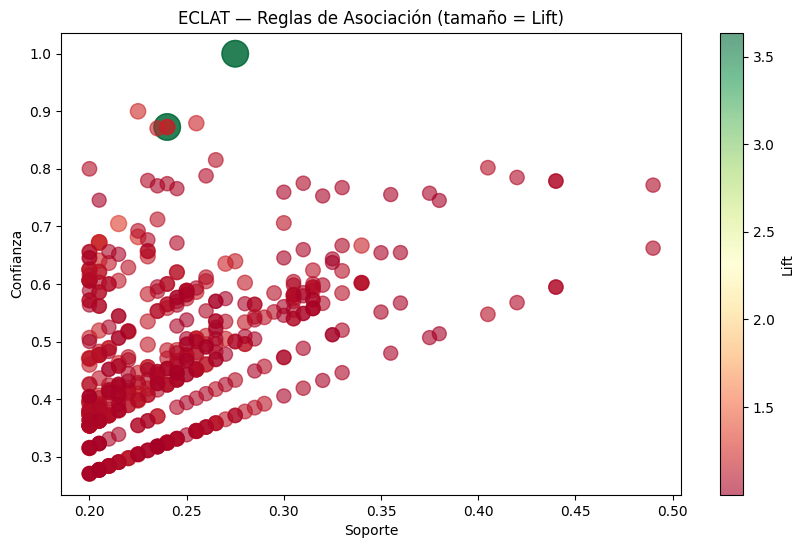

In [28]:
# Propósito: visualizar reglas con dispersión de soporte/confianza y tamaño por lift.
if not rules_df.empty:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rules_df["support"],
        rules_df["confidence"],
        s=rules_df["lift"] * 100,
        alpha=0.6,
        c=rules_df["lift"],
        cmap="RdYlGn",
    )
    plt.colorbar(scatter, label="Lift")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.title("ECLAT — Reglas de Asociación (tamaño = Lift)")
    plt.show()
else:
    print("No hay reglas para visualizar en scatter.")

### Explicación de la celda

En esta celda se generar heatmap de lift para top reglas por affinity.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


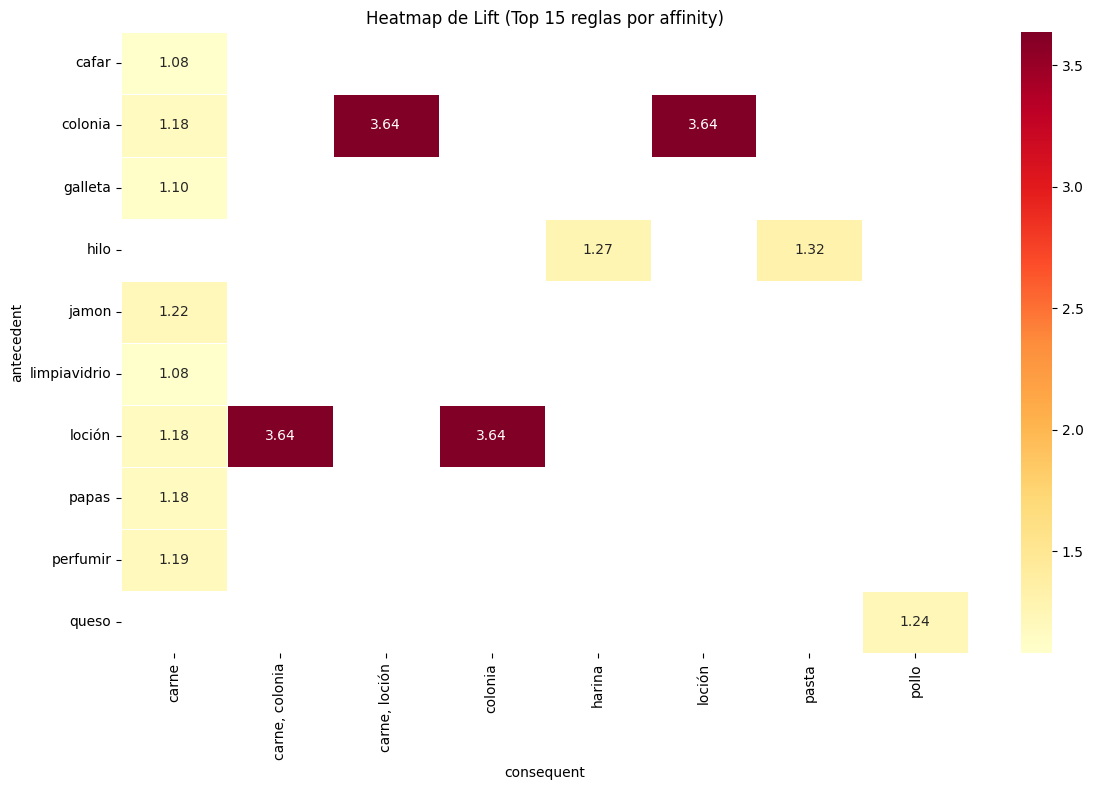

In [29]:
# Propósito: generar heatmap de lift para top reglas por affinity.
if not rules_df.empty:
    top_heat = rules_df.head(15)
    heat_df = top_heat.pivot_table(index='antecedent', columns='consequent', values='lift', aggfunc='mean')

    plt.figure(figsize=(12, 8))
    sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Heatmap de Lift (Top 15 reglas por affinity)')
    plt.tight_layout()
    plt.show()
else:
    print('No hay reglas para visualizar en heatmap.')

### Explicación de la celda

En esta celda se dibujar red de afinidad entre productos con pesos por lift.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


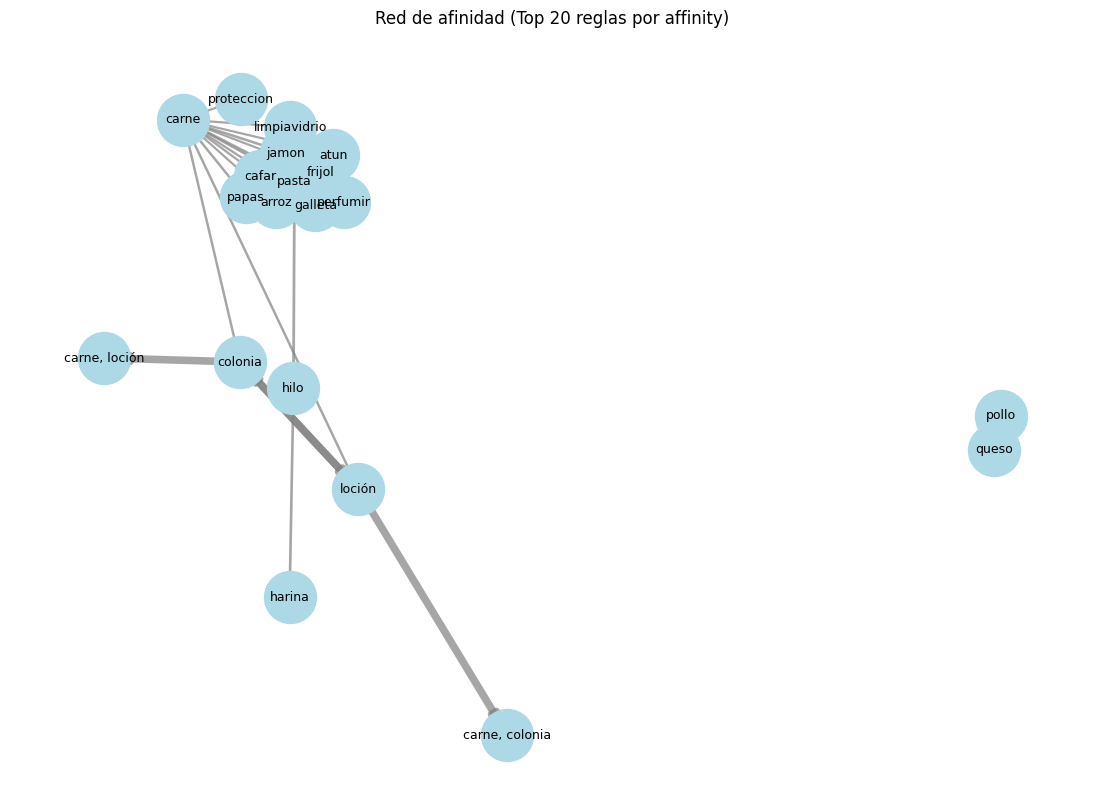

In [30]:
# Propósito: dibujar red de afinidad entre productos con pesos por lift.
if not rules_df.empty:
    top_net = rules_df.head(20)
    graph = nx.DiGraph()

    for _, row in top_net.iterrows():
        ant = row['antecedent']
        con = row['consequent']
        lift = row['lift']
        graph.add_edge(ant, con, weight=lift)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(graph, seed=42)
    widths = [graph[u][v]['weight'] * 1.5 for u, v in graph.edges()]
    nx.draw_networkx_nodes(graph, pos, node_size=1400, node_color='lightblue')
    nx.draw_networkx_labels(graph, pos, font_size=9)
    nx.draw_networkx_edges(graph, pos, width=widths, edge_color='gray', arrows=True, alpha=0.7)
    plt.title('Red de afinidad (Top 20 reglas por affinity)')
    plt.axis('off')
    plt.show()
else:
    print('No hay reglas para visualizar en red de afinidad.')

### Explicación de la celda

En esta celda se mostrar barras de frecuencia para top 20 productos.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


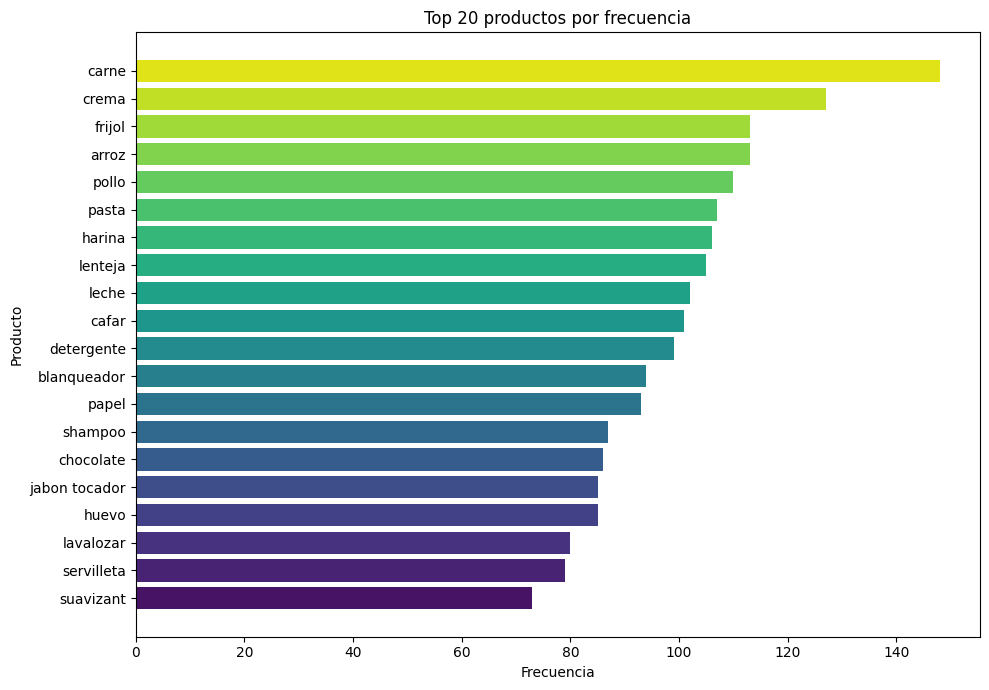

In [31]:
# Propósito: mostrar barras de frecuencia para top 20 productos.
product_freq = productos_df.sum().sort_values(ascending=False).head(20)
colors = sns.color_palette('viridis', n_colors=len(product_freq))

plt.figure(figsize=(10, 7))
plt.barh(product_freq.index[::-1], product_freq.values[::-1], color=colors)
plt.title('Top 20 productos por frecuencia')
plt.xlabel('Frecuencia')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

### Explicación de la celda

En esta celda se mostrar distribución de métricas de reglas (diagnóstico de calidad del modelo).. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


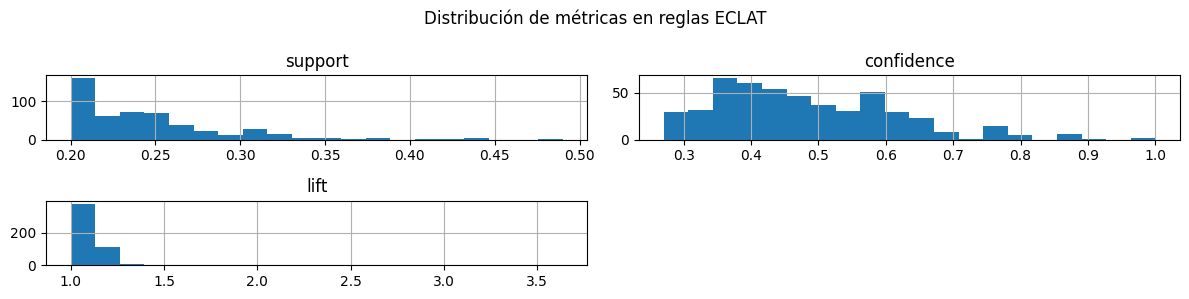

In [32]:
# Propósito: mostrar distribución de métricas de reglas (diagnóstico de calidad del modelo).
if not rules_df.empty:
    rules_df[['support', 'confidence', 'lift']].hist(figsize=(12, 3), bins=20)
    plt.suptitle('Distribución de métricas en reglas ECLAT')
    plt.tight_layout()
    plt.show()
else:
    print('No hay reglas para distribución de métricas.')

## 8. Segmentación por Estrato NSE

**Fase equivalente en `scripts/eclat.ipynb`:** función `eclat_segmento` y comparación por estrato.

En esta versión se estandariza el cálculo de soporte y se separa la lógica en dos celdas independientes: primero cómputo por estrato y luego visualización comparativa.

### Explicación de la celda

En esta celda se ejecutar eclat por estrato y construir comparativo de soporte por producto.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


In [33]:
# Propósito: ejecutar ECLAT por estrato y construir comparativo de soporte por producto.
estrato_results: dict[str, pd.DataFrame] = {}
estrato_support_rows: list[pd.DataFrame] = []

for estrato in sorted(df_final['estrato_nse'].dropna().astype(str).unique()):
    subset = df_final[df_final['estrato_nse'].astype(str) == estrato]
    subset_freq, _, subset_products = run_eclat(subset, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET)
    estrato_results[estrato] = subset_freq

    print(f'\nEstrato {estrato} | registros: {len(subset)}')
    display(subset_freq.head(5))

    product_support = (subset_products.sum() / max(len(subset_products), 1)).rename(estrato)
    estrato_support_rows.append(product_support.to_frame().T)

estrato_support_df = pd.concat(estrato_support_rows, axis=0).fillna(0)
common_top_10 = estrato_support_df.mean(axis=0).sort_values(ascending=False).head(10).index


Estrato E1 | registros: 7


,itemset,support
0,frozenset({carne}),0.7143
1,frozenset({harina}),0.7143
2,frozenset({acondicionador}),0.5714
3,"frozenset({carne, lavalozar, harina})",0.5714
4,frozenset({lavalozar}),0.5714



Estrato E2 | registros: 50


,itemset,support
0,frozenset({carne}),0.72
1,frozenset({crema}),0.62
2,frozenset({arroz}),0.58
3,frozenset({pollo}),0.58
4,frozenset({leche}),0.54



Estrato E3 | registros: 95


,itemset,support
0,frozenset({carne}),0.7368
1,frozenset({crema}),0.6842
2,frozenset({arroz}),0.5895
3,frozenset({harina}),0.5895
4,frozenset({frijol}),0.5895



Estrato E4 | registros: 48


,itemset,support
0,frozenset({carne}),0.7708
1,frozenset({frijol}),0.6875
2,frozenset({blanqueador}),0.6250
3,frozenset({crema}),0.5833
4,"frozenset({carne, frijol})",0.5625


### 8.1 Visualización comparativa por estrato

Esta celda desacopla la etapa de comunicación visual de la etapa de cómputo. Se construye un gráfico de barras agrupadas con los productos de mayor soporte promedio para facilitar comparaciones inter-estrato en contexto comercial.

### Explicación de la celda

En esta celda se visualizar soporte de top productos por estrato nse.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


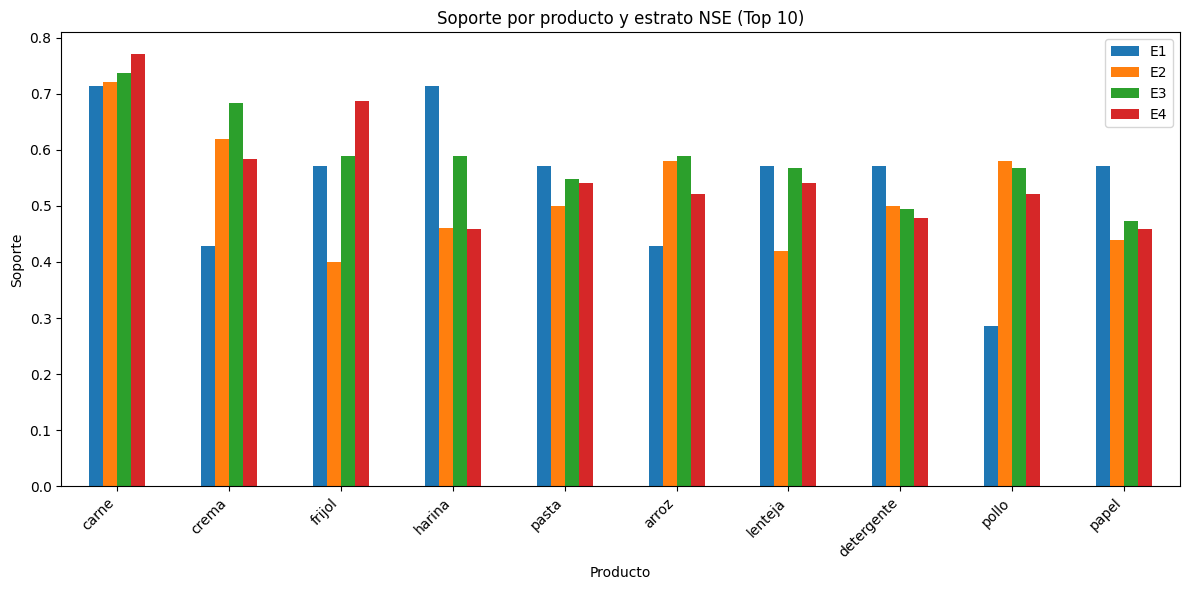

In [34]:
# Propósito: visualizar soporte de top productos por estrato NSE.
estrato_plot_df = estrato_support_df[common_top_10].T
estrato_plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Soporte por producto y estrato NSE (Top 10)')
plt.xlabel('Producto')
plt.ylabel('Soporte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Segmentación por Grupo de Edad

**Fase equivalente en `scripts/eclat.ipynb`:** segmentación por `grupo_edad` con `pd.cut`.

Esta fase también se desacopla en celdas independientes: cálculo de soportes por cohorte etaria y visualización agregada para comparación entre ciclos de vida.

### Explicación de la celda

En esta celda se ejecutar eclat por grupo etario y comparar soportes de productos.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


In [35]:
# Propósito: ejecutar ECLAT por grupo etario y comparar soportes de productos.
edad_results: dict[str, pd.DataFrame] = {}
edad_support_rows: list[pd.DataFrame] = []

for grupo in df_final['grupo_edad'].dropna().astype(str).unique():
    subset = df_final[df_final['grupo_edad'].astype(str) == grupo]
    subset_freq, _, subset_products = run_eclat(subset, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET)
    edad_results[grupo] = subset_freq

    print(f'\nGrupo {grupo} | registros: {len(subset)}')
    display(subset_freq.head(5))

    product_support = (subset_products.sum() / max(len(subset_products), 1)).rename(grupo)
    edad_support_rows.append(product_support.to_frame().T)

edad_support_df = pd.concat(edad_support_rows, axis=0).fillna(0)
common_age_top_10 = edad_support_df.mean(axis=0).sort_values(ascending=False).head(10).index

top_por_grupo = {
    grupo: soportes.sort_values(ascending=False).head(10).index.tolist()
    for grupo, soportes in edad_support_df.iterrows()
}
print('Top productos por grupo etario:')
display(pd.DataFrame.from_dict(top_por_grupo, orient='index').T)


Grupo Joven | registros: 194


,itemset,support
0,frozenset({carne}),0.7526
1,frozenset({crema}),0.6289
2,frozenset({frijol}),0.5722
3,frozenset({arroz}),0.5722
4,frozenset({harina}),0.5464



Grupo Adulto | registros: 1


,itemset,support
0,frozenset({acondicionador}),1.0
1,"frozenset({carne, talco, lavalozar})",1.0
2,"frozenset({carne, suavizant, lavalozar})",1.0
3,"frozenset({carne, pollo, lavalozar})",1.0
4,"frozenset({carne, pasta, lavalozar})",1.0



Grupo Adulto joven | registros: 5


,itemset,support
0,frozenset({blanqueador}),0.8
1,frozenset({crema}),0.8
2,frozenset({hilo}),0.8
3,"frozenset({crema, hilo})",0.8
4,frozenset({acondicionador}),0.6


Top productos por grupo etario:


,Joven,Adulto,Adulto joven
0,carne,acondicionador,blanqueador
1,crema,atun,crema
2,frijol,chocolate,hilo
3,arroz,carne,detergente
4,harina,cafar,chocolate
5,pollo,blanqueador,acondicionador
6,pasta,galleta,desinfectante
7,lenteja,huevo,papel
8,leche,detergente,leche
9,cafar,hilo,pollo


### 9.1 Visualización comparativa por grupo de edad

Se representa el soporte de los productos con mayor frecuencia transversal por ciclo de vida. Este enfoque permite identificar patrones de consumo diferenciados entre cohortes etarias y facilita su comunicación en escenarios académicos y empresariales.

### Explicación de la celda

En esta celda se visualizar soporte de top productos por grupo de edad.. El objetivo es que el flujo del análisis sea claro, reproducible y fácil de interpretar para cualquier persona que revise el notebook.


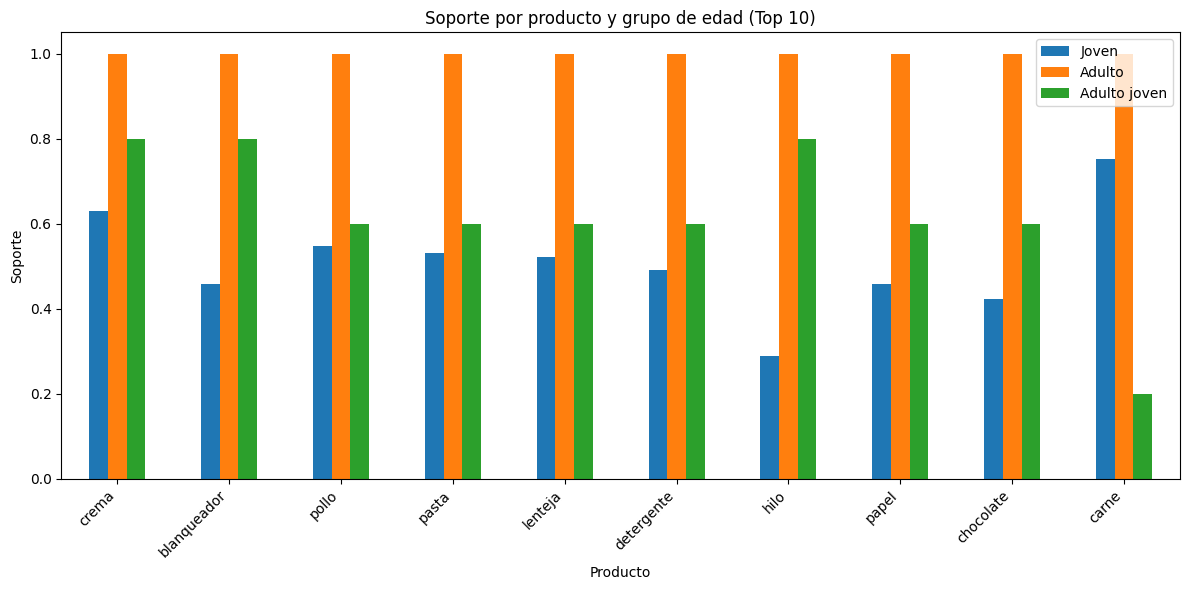

In [36]:
# Propósito: visualizar soporte de top productos por grupo de edad.
edad_plot_df = edad_support_df[common_age_top_10].T
edad_plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Soporte por producto y grupo de edad (Top 10)')
plt.xlabel('Producto')
plt.ylabel('Soporte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Conclusiones y verificación académica

El notebook integra de forma coherente las fases de preparación de datos, modelado con ECLAT, generación de reglas, visualización y segmentación. El resultado principal es una lectura clara de patrones de compra que combina rigor técnico con utilidad práctica para decisiones de negocio. La calidad del análisis mejora al normalizar lenguaje, separar correctamente variables demográficas y de producto, y aplicar una implementación eficiente con cache de soporte para evitar cálculos frágiles.

La verificación de los criterios solicitados queda cubierta a lo largo del flujo completo. La carga y descripción de datos se realiza al inicio con la fuente y el contexto de variables. El preprocesamiento se resuelve mediante limpieza, normalización y transformación transaccional one-hot. El modelo se implementa con parámetros explícitos y funciones reutilizables. Los resultados incluyen reglas relevantes con soporte, confianza y lift. La interpretación se orienta a patrones accionables y comparación entre segmentos. Finalmente, el código mantiene una organización por responsabilidades y un uso adecuado de librerías para análisis de datos, NLP y visualización.

Como siguiente iteración, conviene analizar la sensibilidad de los resultados frente a distintos umbrales de soporte y longitud máxima de itemsets, ampliar el `replace_map` con nuevos hallazgos de baja frecuencia y consolidar una tabla final de reglas priorizadas por segmento para facilitar su presentación ejecutiva.